# Diagnosis Demo


In [1]:
from ukrdc.database import Connection
from sqlalchemy.orm import sessionmaker

engine = Connection.get_engine_from_file(key="ukrdc_staging")

ukrdc3_sessionmaker = sessionmaker(
    autocommit=False, autoflush=False, bind=engine
)

ukrdc3 = ukrdc3_sessionmaker()

In [2]:
from ukrdc_stats.calculators.diagnosis_demographics import RenalDiagnosisStatsCalculator
import datetime as dt
from IPython.display import display
import json


# initialize the demographic stats calculator
calculator = RenalDiagnosisStatsCalculator(ukrdc3, "RJZ")

# run function to extract stats
output = calculator.extract_stats()

# results are returned as pydantic object. To make these easier to 
formatted_output = json.dumps(
    json.loads(
        output.gender.data.json()
    ), 
    indent=4
)

print(formatted_output)


{
    "x": [
        "Female",
        "Female",
        "Female",
        "Female",
        "Female",
        "Male",
        "Male",
        "Male",
        "Male",
        "Male"
    ],
    "y": [
        "Familial / hereditary nephropathies",
        "Glomerular disease",
        "Miscellaneous renal disorders",
        "Systemic diseases affecting the kidney",
        "Tubulointerstitial disease",
        "Familial / hereditary nephropathies",
        "Glomerular disease",
        "Miscellaneous renal disorders",
        "Systemic diseases affecting the kidney",
        "Tubulointerstitial disease"
    ],
    "z": [
        115,
        146,
        171,
        280,
        92,
        106,
        226,
        264,
        611,
        147
    ]
}


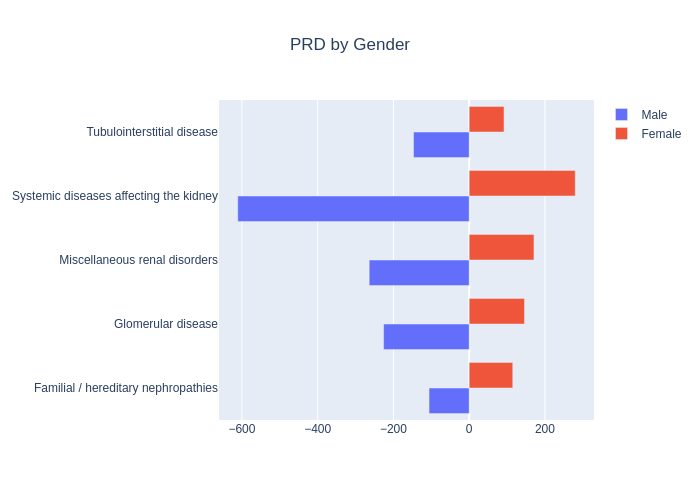

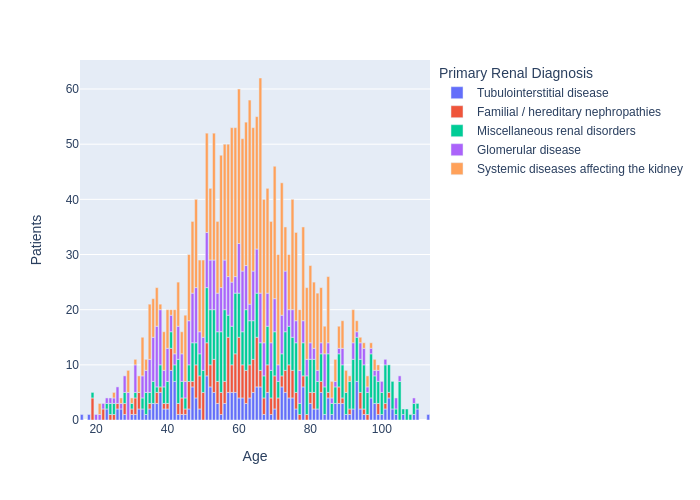

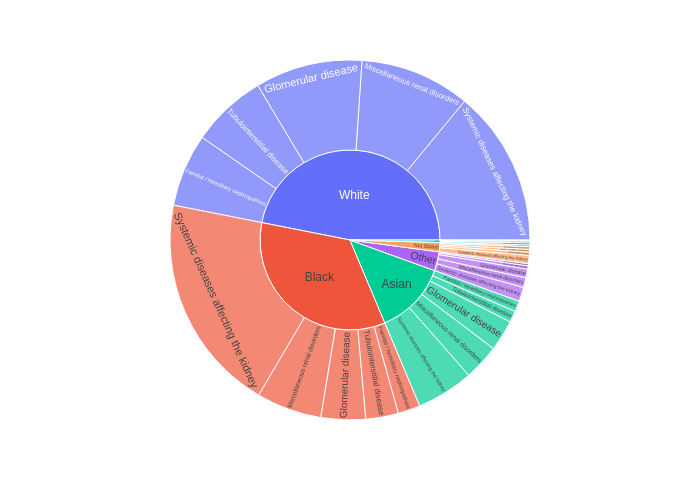

In [3]:
import plotly.graph_objects as go 
import plotly.express as px
import numpy as np
import pandas as pd


back_to_back = pd.DataFrame(output.gender.data.dict())

# Plot gender stats back to back 
data = [
    go.Bar(
        x = -back_to_back[back_to_back.x == "Male"].z,
        y = back_to_back[back_to_back.x == "Male"].y,
        orientation="h",
        name = "Male"
    ), 
    go.Bar(
        x = back_to_back[back_to_back.x == "Female"].z,
        y = back_to_back[back_to_back.x == "Female"].y,
        orientation="h",
        name = "Female"
    ) 
]

fig = go.Figure(
    data=data,
    layout = {
        "title" :{
            "text": output.gender.metadata.title,
            "x" : 0.5,
            "xanchor" : "center" 
        }
    }
)
fig.show("png")

# plot age
stacked_bar_data = pd.DataFrame(output.age.data.dict())
stacked_bar_data.x = pd.to_numeric(stacked_bar_data.x)
stacked_bar_data.rename(columns={"x":"Age", "y":"Primary Renal Diagnosis", "z":"Patients"}, inplace = True)

fig = px.bar(stacked_bar_data, x="Age", y = "Patients", color = "Primary Renal Diagnosis")
fig.show("png")


# plot ethnicity
ethnicity_data = pd.DataFrame(output.ethnic_group.data.dict())
ethnicity_data.rename(columns={"x":"Ethnic Group", "y":"Primary Renal Diagnosis", "z":"Patients"}, inplace = True)
fig = px.sunburst(
    ethnicity_data, 
    path = ["Ethnic Group", "Primary Renal Diagnosis"],
    values = "Patients"
)
fig.show("png")
